In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os

import geopandas as gpd
import pandas as pd
from tqdm import tqdm

from planet_download.client import BasemapsClient

## Load the geometries for initial filtering

We want to get all the basemap quads that overlap with a particular AOI. In this case, we want all the quads that overlap with Kenya's country boundaries. The `series` object will select all the mosaics that are global quarterly (3 mosaics per year [see the [docs](https://assets.planet.com/products/basemap/planet-basemaps-product-specifications.pdf)]), although you can also select `Global Weekly` or `Global Monthly`. By default, this will return all mosaics between a date range (`mosaics` will list all of them, but you can skip this if you just want to download). 

In [36]:
client = BasemapsClient()

kenya = gpd.read_file("kenya.geojson")
bounds_kenya = kenya.total_bounds

start_date = "2020-01-01"
end_date = "2020-12-31"

series = client.series(name="Global Quarterly")

We can explore this object further and see all the quads available between the `start` and `end` date (this might take a while because we're making a ton of requests) 

In [37]:
quads, df = series.all_quads_overlap(
    start_date=start_date, end_date=end_date, bbox=bounds_kenya
)

Now we can plot! You can download all this objects just by using the `download_quads()` function as shown in the README

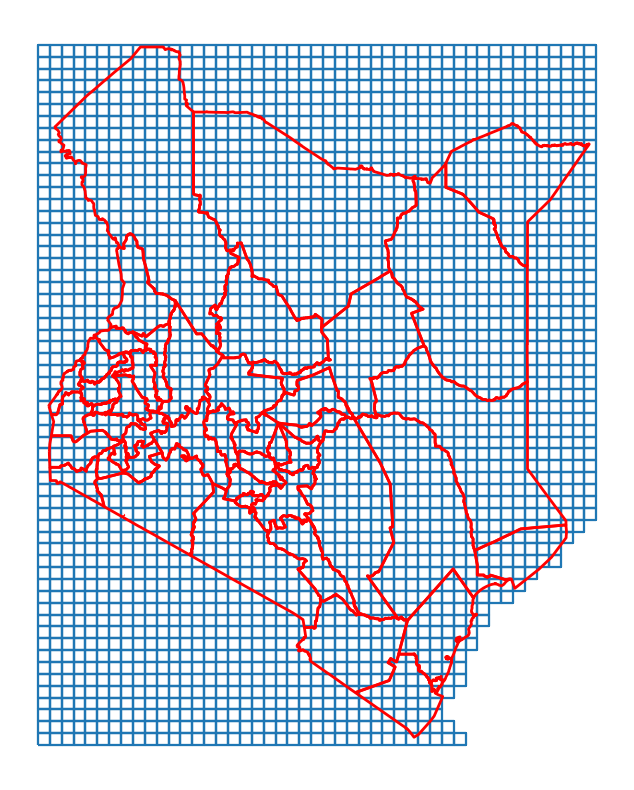

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
df.boundary.plot(ax=ax)
kenya.boundary.plot(ax=ax, color="red", linewidth=2)

ax.set_axis_off()


## More filtering: what happens if I just need a few quads?

We can have a lot of quads, and maybe we don't want or need all of them within the AOI. Using the same `series` class, we can filter the quads to get only the ones that overlap with other AOIs. For instance DHS clusters! We will explore how to do this! 

In [39]:
# Test labels
import geopandas as gpd
import pandas as pd

labels = pd.read_csv("/mnt/sherlock/oak/embed_develop/dhs_data/labels/dhs_labels.csv")

# Transform labels to GeoDataFrame
labels = gpd.GeoDataFrame(
    labels, geometry=gpd.points_from_xy(x=labels.lon, y=labels.lat), crs="EPSG:4326"
).to_crs("EPSG:3857")

# Buffer labels to create a 5000m radius around each point
labels["geometry"] = labels.geometry.buffer(5000, cap_style=3)

# Take back to degrees for plotting
labels = labels.to_crs("EPSG:4326")

We can plot now the smaller cluster over the `quads` and our larger AOI

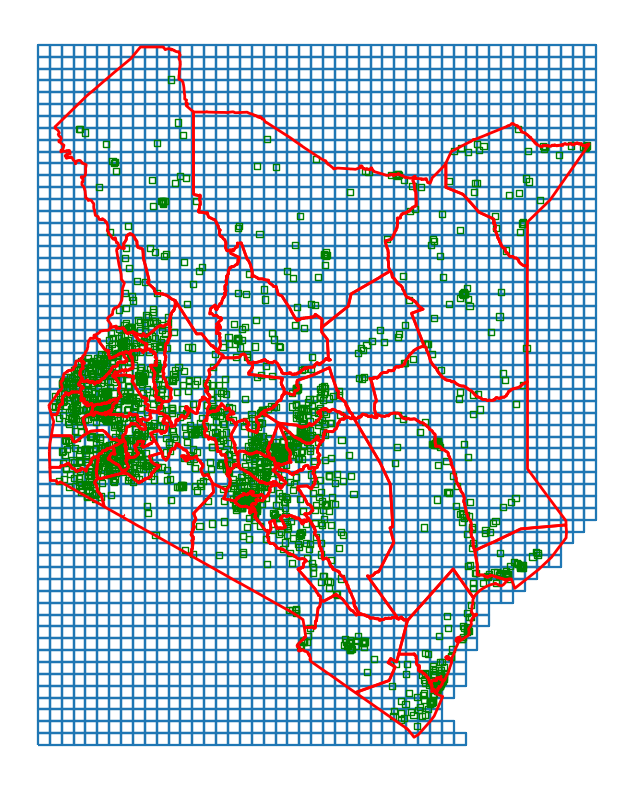

In [40]:
fig, ax = plt.subplots(figsize=(10, 10))
df.boundary.plot(ax=ax)
labels.boundary.plot(ax=ax, color="green", linewidth=1)
kenya.boundary.plot(ax=ax, color="red", linewidth=2)

ax.set_axis_off()

We will calculate the overlap (intersection between the `quads` and the cluster buffers) and take the unique `quads` to only download the objects we need. 

In [41]:
overlap = gpd.sjoin(
    df, labels[labels.year == 2020], how="inner", predicate="intersects"
)
overlap.to_file(
    "/mnt/drive/planet_basemap_downloads/crosswalk_quads_planet_2020.geojson",
    driver="GeoJSON",
)

# Droping duplicates between id and mosaic names (year-quarter). We can have multiple
# quads per label, so we keep those too.
idx = overlap.drop_duplicates(subset=["id", "mosaic_name"]).index.tolist()
sel_quads = [quads[i] for i in idx]

Now, we can download the files in the overlap!

In [30]:
downloads = series.download_selection(
    sel_quads,
    flat=False,
    save_dir="/mnt/drive/planet_basemap_downloads",
    filename_template="{x}_{y}.tif",
    nthreads=10,
)
for download in tqdm(downloads, desc="Downloading files", total=len(sel_quads)):
    pass